In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [6]:
import plotly.express as px

In [7]:
df = pd.read_csv("../export/paraminumet.csv")

In [8]:
df.head()

,param_id,location_id,fecha_inicio,fecha_fin,value,code,granularidad
0,9fef170b-0395-1972-74c8-7e1491f0cd24,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 11:00:00,2022-12-16 12:00:00,0.0,PRECIP_HORARIA,HORA
1,b1f64866-1a71-bca8-ebb1-2b1d6429506f,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 12:00:00,2022-12-16 13:00:00,0.0,PRECIP_HORARIA,HORA
2,600bda49-fce5-d7b0-47b4-7f71e702b14b,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 13:00:00,2022-12-16 14:00:00,0.0,PRECIP_HORARIA,HORA
3,93beb6d6-77d9-dbad-afce-3cadb8b6363a,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 14:00:00,2022-12-16 15:00:00,0.0,PRECIP_HORARIA,HORA
4,81c3d8fe-e6bf-f90c-6397-d35967e154ce,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 15:00:00,2022-12-16 16:00:00,0.0,PRECIP_HORARIA,HORA


In [9]:
estaciones = gpd.read_file("../export/estaciones.geojson")

In [10]:
estaciones_inumet = estaciones[estaciones["type"] == "METEO"]
estaciones_inumet

,nombre,type,id,geometry
0,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892)
1,Mercedes G3,METEO,e1f1c3a0-5d86-8d95-c20c-01d11eecd94d,POINT (-58.0305 -33.2524)
2,Artigas G3,METEO,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,POINT (-56.4667 -30.4)
3,Rocha G3,METEO,fca40b66-3095-bb02-f981-15365abf3389,POINT (-54.3333 -34.4833)
4,Colonia G3,METEO,1bf028c9-b910-8138-0f6d-e56ad8261159,POINT (-57.8398 -34.4626)
5,Salto G3,METEO,e3c05c73-e1e7-3cb0-0e70-cadb7c97ecdb,POINT (-57.9667 -31.3833)
6,Paso de los Toros G3,METEO,78a8b0f9-885d-db62-30cd-67ec7db057ed,POINT (-56.5167 -32.8167)


In [11]:
inumet_registros = estaciones_inumet.merge(df,
                                          left_on = "id",
                                          right_on ="location_id",
                                          how = "left"
                                          ).drop(columns=["location_id"])

inumet_registros.head()

,nombre,type,id,geometry,param_id,fecha_inicio,fecha_fin,value,code,granularidad
0,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892),3d3baa8b-22fd-c5ca-ebc4-2b05d995447d,2026-05-22 05:00:00,2026-05-22 06:00:00,0.0,PRECIP_HORARIA,HORA
1,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892),f8c1fe89-b969-a1d9-384d-45c11e409f7c,2026-05-22 06:00:00,2026-05-22 07:00:00,0.0,PRECIP_HORARIA,HORA
2,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892),9ee7fece-fd03-ad9a-3a3d-da628e69edc7,2026-05-22 07:00:00,2026-05-22 08:00:00,0.0,PRECIP_HORARIA,HORA
3,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892),7d4b19b3-e3ad-6b4a-d20a-b6e0be02e0df,2026-05-22 08:00:00,2026-05-22 09:00:00,0.0,PRECIP_HORARIA,HORA
4,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892),6df56e16-531c-1036-df17-1eb02047aa92,2026-05-22 09:00:00,2026-05-22 10:00:00,0.0,PRECIP_HORARIA,HORA


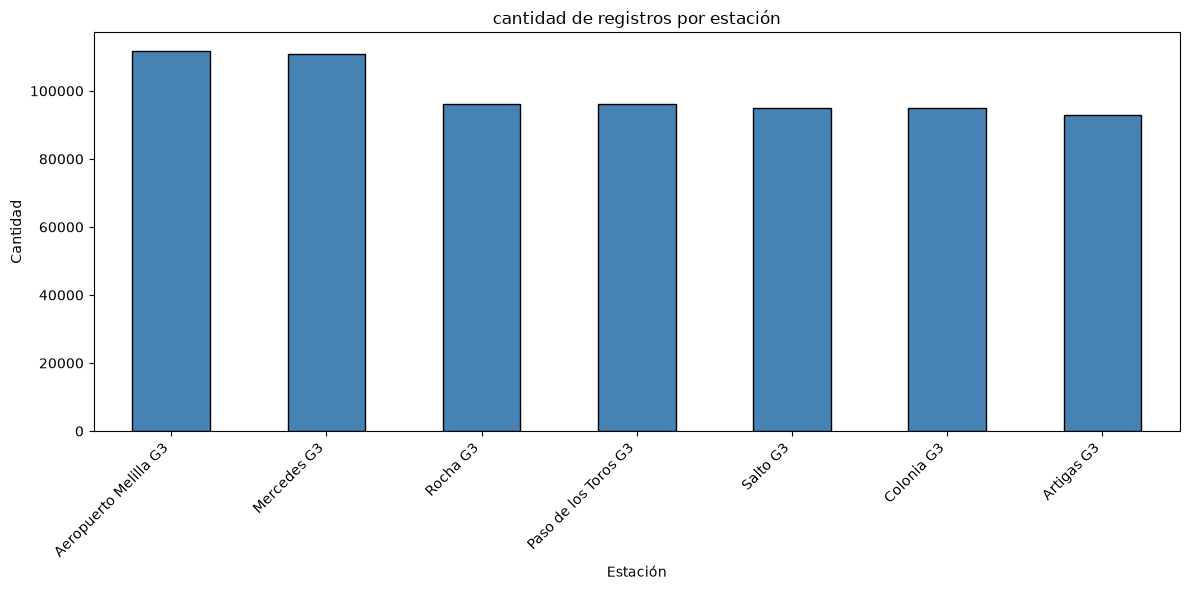

In [12]:
# Gráfica cantidad de estaciones vs localidad
conteo = inumet_registros["nombre"].value_counts()
plt.figure(figsize=(12,6))
conteo.plot(kind = "bar", color= "steelblue", edgecolor = "black")

plt.title("cantidad de registros por estación")
plt.xlabel("Estación")
plt.ylabel("Cantidad")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()


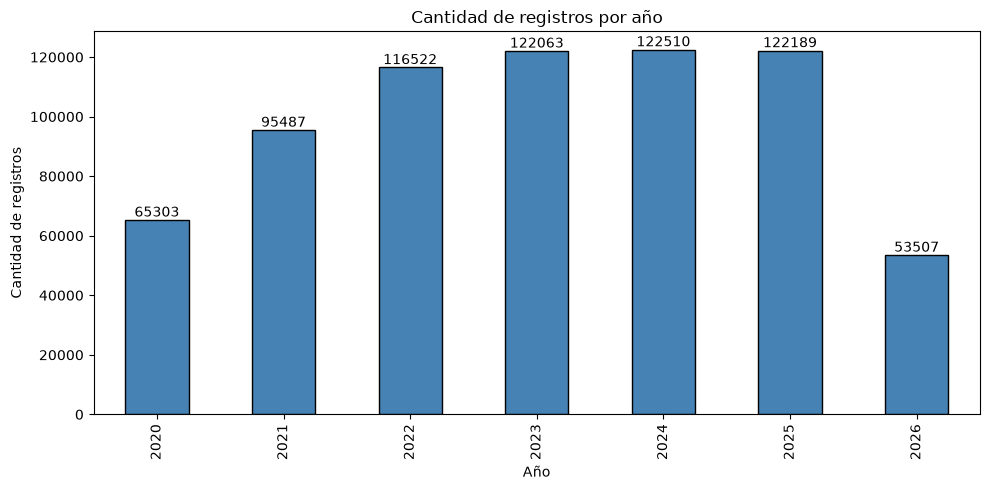

In [13]:
# Extraer el año de la fecha
inumet_registros["año"] = pd.to_datetime(inumet_registros["fecha_inicio"]).dt.year

# Contar registros por año
por_año = inumet_registros["año"].value_counts().sort_index()

# Graficar en barras
plt.figure(figsize=(10, 5))
ax = por_año.plot(kind="bar", color="steelblue", edgecolor="black")

# Números arriba de cada barra
for i, v in enumerate(por_año):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

In [41]:
type(inumet_registros) #pronto

geopandas.geodataframe.GeoDataFrame

#### Variables Climaticas

In [14]:
df_tempprec = pd.read_csv("../export/registrotempprec.csv")

In [15]:
df_tempprec.head()

,registro_id,location_id,fecha_inicio,fecha_fin,temperatura_maxima,temperatura_minima,pluviometro,granularidad
0,ee6a5273-8ffc-c622-74ad-b91f7e533f77,90cc6928-919a-87cf-a3a5-12da7ca6598d,2026-01-01 09:00:00,2026-01-02 08:59:59,27.4,21.7,0.0,DIA
1,5d1621fc-4f61-7733-a25a-6250dd72c109,90cc6928-919a-87cf-a3a5-12da7ca6598d,2026-01-02 09:00:00,2026-01-03 08:59:59,27.4,16.3,0.0,DIA
2,ab8e726b-3bde-71ed-7c03-d1852d99f6e9,90cc6928-919a-87cf-a3a5-12da7ca6598d,2026-01-03 09:00:00,2026-01-04 08:59:59,21.3,13.5,0.0,DIA
3,b09dd4db-c5aa-a5ac-8954-246293c17629,90cc6928-919a-87cf-a3a5-12da7ca6598d,2026-01-04 09:00:00,2026-01-05 08:59:59,23.4,10.6,0.0,DIA
4,3fcc8336-6d1e-cb01-866b-92688eebd490,90cc6928-919a-87cf-a3a5-12da7ca6598d,2026-01-05 09:00:00,2026-01-06 08:59:59,28.5,11.4,0.0,DIA


In [16]:
estaciones_clima = estaciones[estaciones["type"] == "CLIMA"]
estaciones_clima

,nombre,type,id,geometry
7,La Estanzuela,CLIMA,90cc6928-919a-87cf-a3a5-12da7ca6598d,POINT (-57.69222 -34.33722)
8,Las Brujas,CLIMA,b2563995-2428-ca51-2c64-bd6d435f721b,POINT (-56.34 -34.67)
9,SaltoGrande,CLIMA,4615a52b-d0be-4da2-8689-942c729a0c11,POINT (-57.89083 -31.27278)
10,Tacuarembo,CLIMA,a49c92b2-216e-4d62-f322-224a469ae7e0,POINT (-55.82667 -31.70889)
11,Treinta y Tres,CLIMA,3f96c830-bd99-4454-0014-59335f987dd0,POINT (-54.17222 -33.275)


In [17]:
clima_registros = estaciones_clima.merge(df_tempprec,
                                          left_on = "id",
                                          right_on ="location_id",
                                          how = "left"
                                          ).drop(columns=["location_id", "fecha_fin", "registro_id", "id", "type"])

clima_registros.head()

,nombre,geometry,fecha_inicio,temperatura_maxima,temperatura_minima,pluviometro,granularidad
0,La Estanzuela,POINT (-57.69222 -34.33722),2026-01-01 09:00:00,27.4,21.7,0.0,DIA
1,La Estanzuela,POINT (-57.69222 -34.33722),2026-01-02 09:00:00,27.4,16.3,0.0,DIA
2,La Estanzuela,POINT (-57.69222 -34.33722),2026-01-03 09:00:00,21.3,13.5,0.0,DIA
3,La Estanzuela,POINT (-57.69222 -34.33722),2026-01-04 09:00:00,23.4,10.6,0.0,DIA
4,La Estanzuela,POINT (-57.69222 -34.33722),2026-01-05 09:00:00,28.5,11.4,0.0,DIA


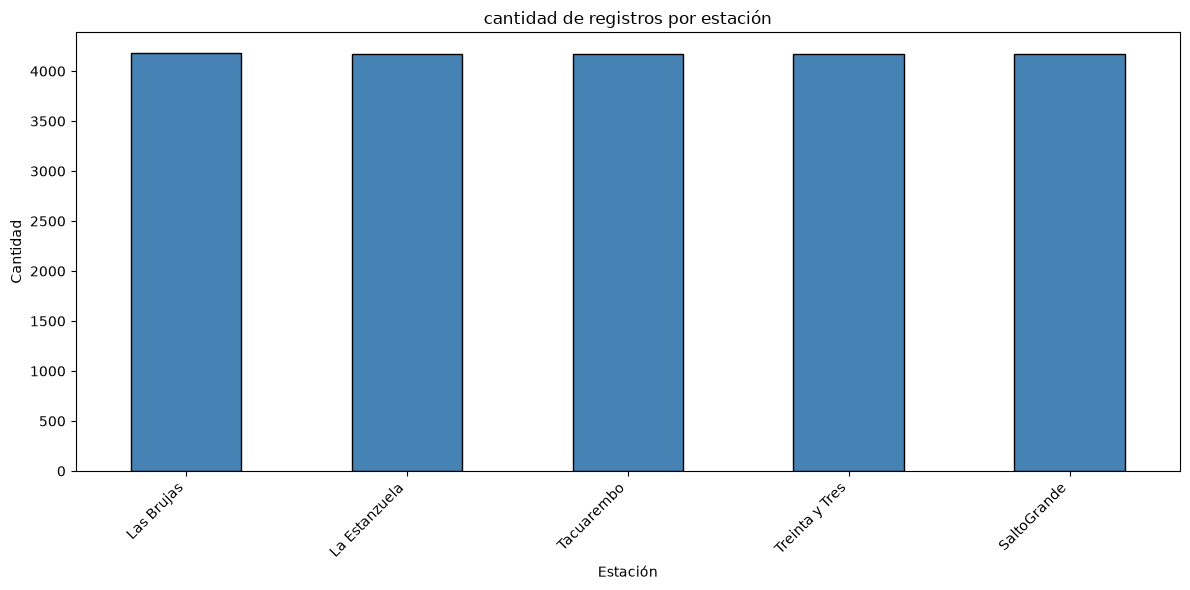

In [18]:
# Gráfica cantidad de estaciones vs localidad
conteo = clima_registros["nombre"].value_counts()
plt.figure(figsize=(12,6))
conteo.plot(kind = "bar", color= "steelblue", edgecolor = "black")

plt.title("cantidad de registros por estación")
plt.xlabel("Estación")
plt.ylabel("Cantidad")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
print("Rango de tiempo: ")
clima_registros["fecha_inicio"].min(), clima_registros["fecha_inicio"].max()

Rango de tiempo: 


('2015-01-01 09:00:00', '2026-06-10 09:00:00')

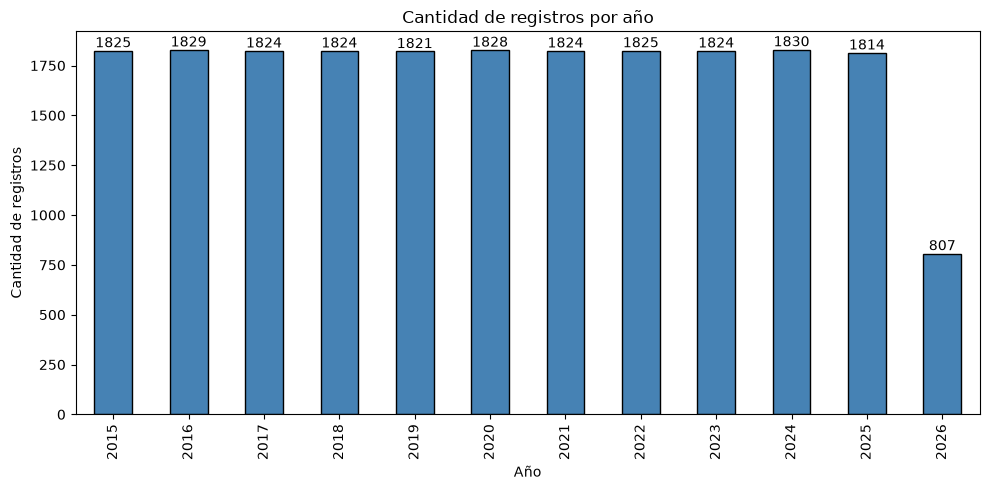

In [20]:
clima_registros["año"] = pd.to_datetime(clima_registros["fecha_inicio"]).dt.year

por_año = clima_registros["año"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = por_año.plot(kind="bar", color="steelblue", edgecolor="black")

for i, v in enumerate(por_año):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

In [43]:
type(clima_registros) #pronto

geopandas.geodataframe.GeoDataFrame

Visualización de Datos de erosion cunecas y erosion suelos (98 cuencas uruguayas)

In [21]:
df_erosions = pd.read_csv("../export/erosion_suelos.csv")
df_erosionc = pd.read_csv("../export/erosion_cuenca.csv")



In [22]:
df_erosionc.head()

,erosion_id,area_id,ponderacion_erosion,cluster
0,2eab29de-34ae-bd8d-7d98-478c742dd546,5663b021-de07-0a06-b359-8782c75bcdd6,1.069,3
1,8c795146-c674-9e2a-005d-4905aac0ebf9,b1252d19-3c15-d252-7b1a-1c6809465596,0.785,3
2,04b7cf30-ba7b-5d5c-4dd8-490ac81c89fb,1f101080-6341-888d-8980-31b80db28fcd,3.365,1
3,0b08f4a8-9dda-590e-79ce-9206f53aade2,381892d6-ed30-6909-a8e5-cb93b226b944,5.534,1
4,463c393d-6578-19da-9276-3e959acd2321,f631841b-56a7-c26b-ea85-1b5689fd5a53,3.154,1


In [23]:
df_erosions.head() 

,erosion_id,area_id,grupo_coneat,perfil_modal,factor_k,taxonomia
0,aefdf640-2e42-44ac-2691-472a5d9fd84b,9d2f3f61-2855-52df-43f6-a9350a4d3bd9,03.52,P21-09,0.544156,Brunosol Subutrico Tpico LAc
1,2157271f-be2c-592b-45b7-f67b10b8ef8f,fde637a6-06d0-c1c7-38e5-f88a05a784bd,1.10b,M13-06,0.230000,"Litosol Eutrico Melnico F, ms"
2,5efb805a-ee90-6a50-9541-113fcdda6bb7,9eb369eb-2bc5-e7ac-d1ea-39257d8a10ce,12.11,USDA 5,0.115000,Vertisol Rptico Tpico LAc
3,8446759e-4f3f-7c5f-9e3a-0644228c4ce9,b3622e8b-bbbf-3fbf-d1c4-cfc5fdf34c39,1.11a,M13-07,0.260000,"Litosol Eutrico Melnico LAc, s"
4,6edce402-b263-58e4-98bc-21dc3089c42c,9563a1d0-305c-f995-b812-534d123c0a43,1.23,K12-02,0.462149,"Brunosol utrico Tpico AcL,s"


In [24]:
df_cuencas = gpd.read_file("../export/cuencas.geojson")

In [25]:
df_cuencas.head(100)

,nombre,id,geometry
0,Olimar Grande_1,5663b021-de07-0a06-b359-8782c75bcdd6,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
1,A_San Miguel,b1252d19-3c15-d252-7b1a-1c6809465596,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936..."
2,A_Guaviyu,1f101080-6341-888d-8980-31b80db28fcd,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ..."
3,A_San Antonio,381892d6-ed30-6909-a8e5-cb93b226b944,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574..."
4,AREA_A,f631841b-56a7-c26b-ea85-1b5689fd5a53,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679..."
...,...,...,...
94,A_Tacuari,ee0acd77-e33e-2773-3139-7e6246b6b268,"MULTIPOLYGON (((-54.44618 -32.74359, -54.44381..."
95,A_De Vera,6ca65d69-5769-a094-2c50-fe7bf7ff7207,"MULTIPOLYGON (((-57.54576 -33.26093, -57.5376 ..."
96,A_Parao_2,81f316bd-bf99-2d1c-f1f8-2248b55626f9,"MULTIPOLYGON (((-54.1557 -33.1657, -54.13696 -..."
97,A_Rosario,7da99843-3b97-fecc-28fd-884be15e92df,"MULTIPOLYGON (((-57.42939 -34.30251, -57.42326..."


In [26]:
df_suelos = gpd.read_file("../export/suelos.geojson")

In [38]:
type(df_suelos)

geopandas.geodataframe.GeoDataFrame

In [27]:
df_suelos.head()

,nombre,id,geometry
0,SIN_NOMBRE,9d2f3f61-2855-52df-43f6-a9350a4d3bd9,"MULTIPOLYGON (((-56.99856 -30.10576, -56.99809..."
1,SIN_NOMBRE,fde637a6-06d0-c1c7-38e5-f88a05a784bd,"MULTIPOLYGON (((-56.95293 -30.10578, -56.95055..."
2,SIN_NOMBRE,9eb369eb-2bc5-e7ac-d1ea-39257d8a10ce,"MULTIPOLYGON (((-56.97696 -30.10387, -56.97454..."
3,SIN_NOMBRE,b3622e8b-bbbf-3fbf-d1c4-cfc5fdf34c39,"MULTIPOLYGON (((-57.08114 -30.11195, -57.07903..."
4,SIN_NOMBRE,9563a1d0-305c-f995-b812-534d123c0a43,"MULTIPOLYGON (((-56.80576 -30.12439, -56.8078 ..."


In [28]:
erosionc_registros = df_cuencas.merge(df_erosionc,
                                          left_on = "id",
                                          right_on ="area_id",
                                          how = "left"
                                          )#.drop(columns=["location_id"])

erosionc_registros.head()

,nombre,id,geometry,erosion_id,area_id,ponderacion_erosion,cluster
0,Olimar Grande_1,5663b021-de07-0a06-b359-8782c75bcdd6,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ...",2eab29de-34ae-bd8d-7d98-478c742dd546,5663b021-de07-0a06-b359-8782c75bcdd6,1.069,3
1,A_San Miguel,b1252d19-3c15-d252-7b1a-1c6809465596,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936...",8c795146-c674-9e2a-005d-4905aac0ebf9,b1252d19-3c15-d252-7b1a-1c6809465596,0.785,3
2,A_Guaviyu,1f101080-6341-888d-8980-31b80db28fcd,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ...",04b7cf30-ba7b-5d5c-4dd8-490ac81c89fb,1f101080-6341-888d-8980-31b80db28fcd,3.365,1
3,A_San Antonio,381892d6-ed30-6909-a8e5-cb93b226b944,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574...",0b08f4a8-9dda-590e-79ce-9206f53aade2,381892d6-ed30-6909-a8e5-cb93b226b944,5.534,1
4,AREA_A,f631841b-56a7-c26b-ea85-1b5689fd5a53,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679...",463c393d-6578-19da-9276-3e959acd2321,f631841b-56a7-c26b-ea85-1b5689fd5a53,3.154,1


In [29]:
erosions_registros = df_suelos.merge(df_erosions,
                                          left_on = "id",
                                          right_on ="area_id",
                                          how = "left"
                                          ).drop(columns=["nombre"])

erosions_registros.head()

,id,geometry,erosion_id,area_id,grupo_coneat,perfil_modal,factor_k,taxonomia
0,9d2f3f61-2855-52df-43f6-a9350a4d3bd9,"MULTIPOLYGON (((-56.99856 -30.10576, -56.99809...",aefdf640-2e42-44ac-2691-472a5d9fd84b,9d2f3f61-2855-52df-43f6-a9350a4d3bd9,03.52,P21-09,0.544156,Brunosol Subutrico Tpico LAc
1,fde637a6-06d0-c1c7-38e5-f88a05a784bd,"MULTIPOLYGON (((-56.95293 -30.10578, -56.95055...",2157271f-be2c-592b-45b7-f67b10b8ef8f,fde637a6-06d0-c1c7-38e5-f88a05a784bd,1.10b,M13-06,0.230000,"Litosol Eutrico Melnico F, ms"
2,9eb369eb-2bc5-e7ac-d1ea-39257d8a10ce,"MULTIPOLYGON (((-56.97696 -30.10387, -56.97454...",5efb805a-ee90-6a50-9541-113fcdda6bb7,9eb369eb-2bc5-e7ac-d1ea-39257d8a10ce,12.11,USDA 5,0.115000,Vertisol Rptico Tpico LAc
3,b3622e8b-bbbf-3fbf-d1c4-cfc5fdf34c39,"MULTIPOLYGON (((-57.08114 -30.11195, -57.07903...",8446759e-4f3f-7c5f-9e3a-0644228c4ce9,b3622e8b-bbbf-3fbf-d1c4-cfc5fdf34c39,1.11a,M13-07,0.260000,"Litosol Eutrico Melnico LAc, s"
4,9563a1d0-305c-f995-b812-534d123c0a43,"MULTIPOLYGON (((-56.80576 -30.12439, -56.8078 ...",6edce402-b263-58e4-98bc-21dc3089c42c,9563a1d0-305c-f995-b812-534d123c0a43,1.23,K12-02,0.462149,"Brunosol utrico Tpico AcL,s"


In [ ]:
type(erosions_registros) #pronto

In [40]:
type(erosionc_registros) #pronto

geopandas.geodataframe.GeoDataFrame

In [30]:
df_erosions.shape, df_erosionc.shape

((33563, 6), (99, 4))

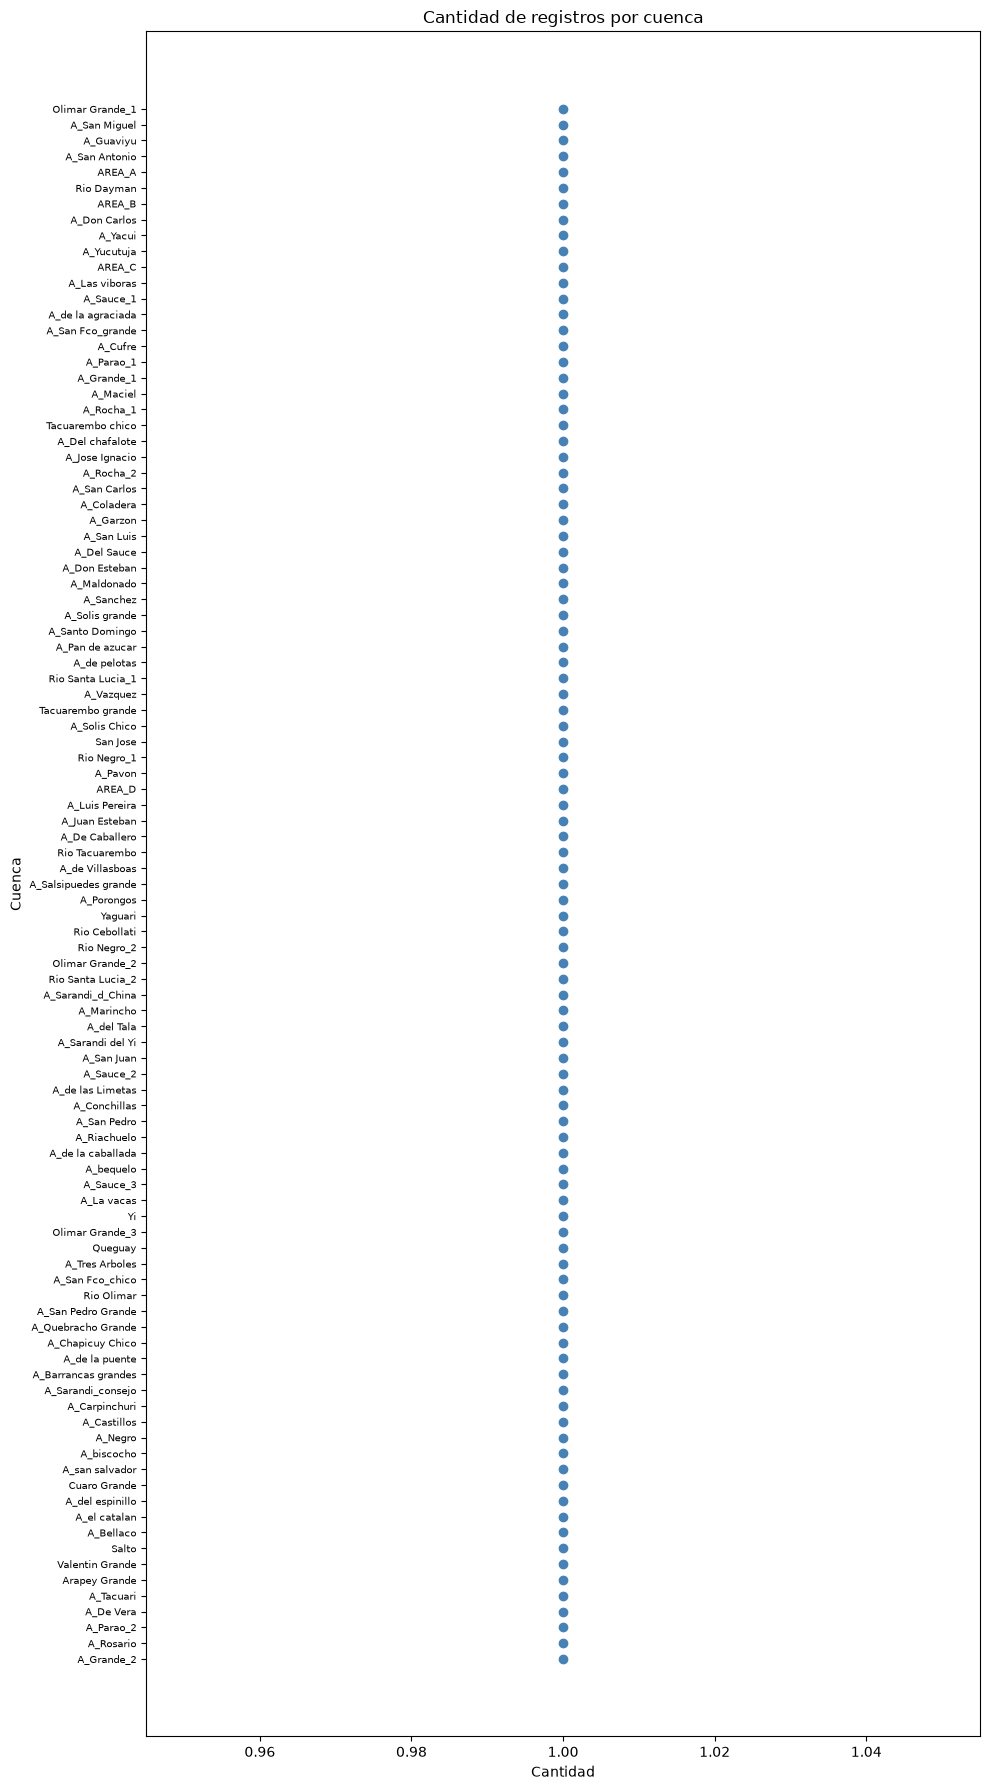

In [31]:
conteo = erosionc_registros["nombre"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,18))
plt.scatter(conteo.values, range(len(conteo)), color="steelblue")
plt.yticks(range(len(conteo)), conteo.index, fontsize=7)
plt.title("Cantidad de registros por cuenca")
plt.xlabel("Cantidad")
plt.ylabel("Cuenca")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
#Puntos de Grillas : PAD/ANR/IBH

In [33]:
df_puntos_mediciones = pd.read_csv("../export/puntomedicion.csv")

In [34]:
df_puntos_grilla = gpd.read_file("../export/puntos_grilla.geojson")

In [35]:
df_puntos_mediciones.head()

,medicion_id,punto_id,value,type,fecha_inicio,fecha_fin,granularidad
0,37c10d68-3d4d-dfe8-a89d-806def58bb0a,c04728d8-baf3-486f-6142-4aaa204f7768,51.134426,IBH,2026-01-01,2026-01-10,PERIODO
1,cb4c0933-7e09-69fb-971a-418a7e6b4497,c04728d8-baf3-486f-6142-4aaa204f7768,47.272720,IBH,2026-01-11,2026-01-20,PERIODO
2,b17d5b5f-6dd1-296e-11ca-1d97088f6299,c04728d8-baf3-486f-6142-4aaa204f7768,35.141479,IBH,2026-01-21,2026-01-31,PERIODO
3,e47ae754-7f1f-8c24-dd44-e972bcb32c8f,c04728d8-baf3-486f-6142-4aaa204f7768,22.802099,IBH,2026-02-01,2026-02-10,PERIODO
4,73824ade-0dc2-99cf-7548-58cd0adc290e,c04728d8-baf3-486f-6142-4aaa204f7768,61.485435,IBH,2026-02-11,2026-02-20,PERIODO


In [36]:
df_puntos_grilla.head()

,id,geometry
0,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667)
1,4c891bfa-5272-f3d5-6390-e2e5294c8240,POINT (-56.6667 -34.6667)
2,9236e94f-f039-166e-69ae-b6920e6aa389,POINT (-56.3333 -34.6667)
3,11fe1515-95cb-fbc4-1e7b-f219cb94da80,POINT (-56 -34.6667)
4,84f697c9-da70-37b3-85e5-3fcf817a5ed1,POINT (-55.6667 -34.6667)


In [37]:
#type(df_puntos_grilla)

geopandas.geodataframe.GeoDataFrame

In [62]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [47]:
# separacion de datos:
mediciones_PAD = df_puntos_mediciones[df_puntos_mediciones["type"] == "PAD"]
mediciones_PAD

,medicion_id,punto_id,value,type,fecha_inicio,fecha_fin,granularidad
2685,67e0c1f6-3595-838a-deef-86935d261e5d,c04728d8-baf3-486f-6142-4aaa204f7768,30.468628,PAD,2026-01-01,2026-01-10,PERIODO
2686,e81e377b-9b3f-68ad-d71f-6eb8338fe9f9,c04728d8-baf3-486f-6142-4aaa204f7768,38.351505,PAD,2026-01-11,2026-01-20,PERIODO
2687,b8e79b59-252d-dd80-4354-d231b572d529,c04728d8-baf3-486f-6142-4aaa204f7768,26.582043,PAD,2026-01-21,2026-01-31,PERIODO
2688,baa8534b-ae1f-812d-33a4-1b3843d34d50,c04728d8-baf3-486f-6142-4aaa204f7768,18.453136,PAD,2026-02-01,2026-02-10,PERIODO
2689,36a3b721-2702-29d1-39f8-d65e7c63c465,c04728d8-baf3-486f-6142-4aaa204f7768,26.715754,PAD,2026-02-11,2026-02-20,PERIODO
...,...,...,...,...,...,...,...
150355,1410db92-4c7e-5140-7fa3-3df30ebcd969,06578bbe-4c37-f6be-ae7a-1657b2d756db,55.077953,PAD,2025-11-11,2025-11-20,PERIODO
150356,7d4dd526-f363-1c8d-2a3c-5a568f5d0924,06578bbe-4c37-f6be-ae7a-1657b2d756db,53.099083,PAD,2025-11-21,2025-11-30,PERIODO
150357,aef59d84-c58a-48d8-c2d4-f163cc0cad51,06578bbe-4c37-f6be-ae7a-1657b2d756db,40.477486,PAD,2025-12-01,2025-12-10,PERIODO
150358,fd2875b7-1520-b1bf-85f4-13ea465cd948,06578bbe-4c37-f6be-ae7a-1657b2d756db,47.249233,PAD,2025-12-11,2025-12-20,PERIODO


In [51]:
PAD_registros = df_puntos_grilla.merge(mediciones_PAD,
                                          left_on = "id",
                                          right_on ="punto_id",
                                          how = "left"
                                          ).drop(columns=["punto_id", "medicion_id"])

PAD_registros.head()

,id,geometry,value,type,fecha_inicio,fecha_fin,granularidad
0,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),63.014845,PAD,2015-01-01,2015-01-10,PERIODO
1,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),67.066294,PAD,2015-01-11,2015-01-20,PERIODO
2,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),69.862484,PAD,2015-01-21,2015-01-31,PERIODO
3,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),67.005593,PAD,2015-02-01,2015-02-10,PERIODO
4,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),53.399872,PAD,2015-02-11,2015-02-20,PERIODO


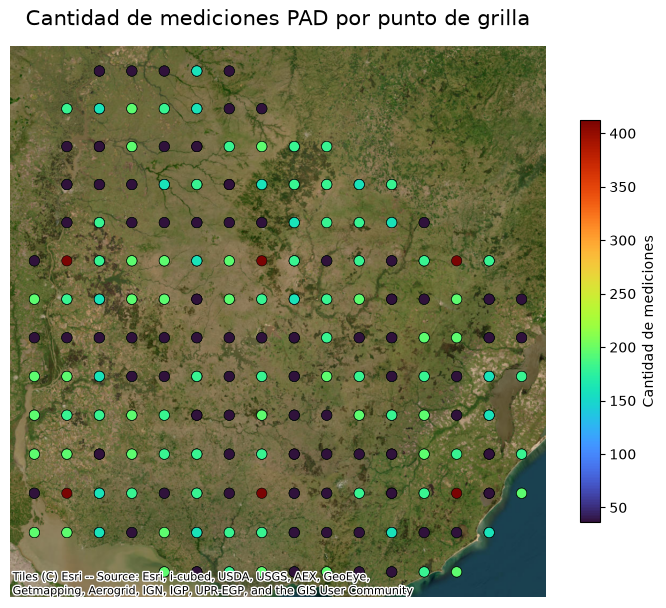

In [98]:
# 1. Contar mediciones por punto (por id)
conteo = PAD_registros.groupby("id").agg(
    n_mediciones=("value", "size"),
    geometry=("geometry", "first")
).reset_index()

# 2. GeoDataFrame y reproyección a Web Mercator (necesario para el fondo)
gdf = gpd.GeoDataFrame(conteo, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)

# 3. Figura
fig, ax = plt.subplots(figsize=(7, 7))

# 4. Puntos coloreados por cantidad de mediciones + escala de referencia
gdf.plot(
    ax=ax,
    column="n_mediciones",
    cmap="turbo",              # rampa vistosa; probá "YlOrRd" o "plasma"
    markersize=55,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "Cantidad de mediciones", "shrink": 0.6},
    zorder=2
)

# 5. Mapa geográfico de fondo (Uruguay real)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)   # satelital
# Si preferís mapa tipo calle/relieve en vez de satelital, usá:
# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Cantidad de mediciones PAD por punto de grilla", fontsize=15, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

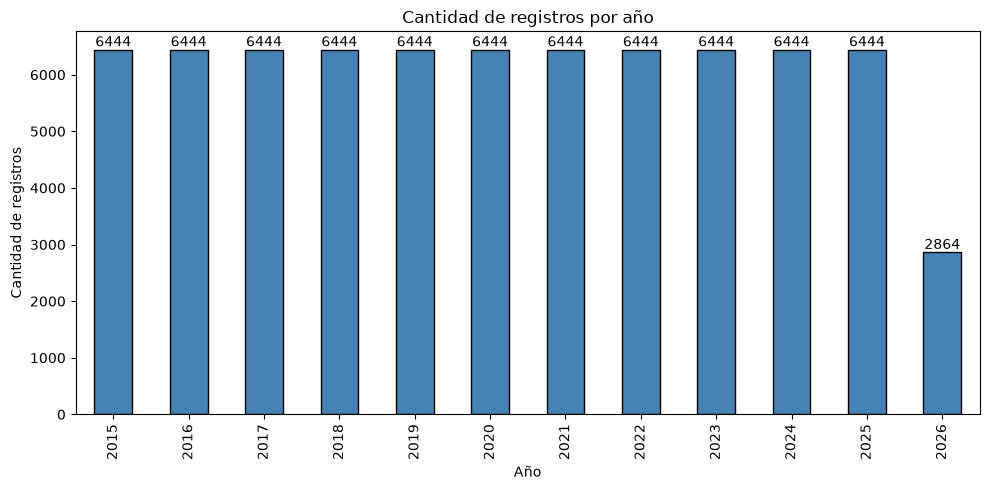

In [89]:
PAD_registros["año"] = pd.to_datetime(PAD_registros["fecha_inicio"]).dt.year.astype("Int64")

por_año = PAD_registros["año"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = por_año.plot(kind="bar", color="steelblue", edgecolor="black")

for i, v in enumerate(por_año):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

In [79]:
type(PAD_registros)

geopandas.geodataframe.GeoDataFrame

In [67]:
mediciones_IBH = df_puntos_mediciones[df_puntos_mediciones["type"] == "IBH"]
mediciones_IBH

,medicion_id,punto_id,value,type,fecha_inicio,fecha_fin,granularidad
0,37c10d68-3d4d-dfe8-a89d-806def58bb0a,c04728d8-baf3-486f-6142-4aaa204f7768,51.134426,IBH,2026-01-01,2026-01-10,PERIODO
1,cb4c0933-7e09-69fb-971a-418a7e6b4497,c04728d8-baf3-486f-6142-4aaa204f7768,47.272720,IBH,2026-01-11,2026-01-20,PERIODO
2,b17d5b5f-6dd1-296e-11ca-1d97088f6299,c04728d8-baf3-486f-6142-4aaa204f7768,35.141479,IBH,2026-01-21,2026-01-31,PERIODO
3,e47ae754-7f1f-8c24-dd44-e972bcb32c8f,c04728d8-baf3-486f-6142-4aaa204f7768,22.802099,IBH,2026-02-01,2026-02-10,PERIODO
4,73824ade-0dc2-99cf-7548-58cd0adc290e,c04728d8-baf3-486f-6142-4aaa204f7768,61.485435,IBH,2026-02-11,2026-02-20,PERIODO
...,...,...,...,...,...,...,...
79471,c68f9b37-df91-a352-56cf-b22452f7d516,06578bbe-4c37-f6be-ae7a-1657b2d756db,69.564087,IBH,2025-11-11,2025-11-20,PERIODO
79472,073851ac-8697-36c8-a67a-8dc71c0234dd,06578bbe-4c37-f6be-ae7a-1657b2d756db,65.464714,IBH,2025-11-21,2025-11-30,PERIODO
79473,15615f3e-3158-961b-5815-78fc6764a559,06578bbe-4c37-f6be-ae7a-1657b2d756db,51.072136,IBH,2025-12-01,2025-12-10,PERIODO
79474,b52ef2ec-74e6-f91e-e02a-e57ece024bab,06578bbe-4c37-f6be-ae7a-1657b2d756db,58.329884,IBH,2025-12-11,2025-12-20,PERIODO


In [63]:
IBH_registros = df_puntos_grilla.merge(mediciones_IBH,
                                          left_on = "id",
                                          right_on ="punto_id",
                                          how = "left"
                                          ).drop(columns=["punto_id", "medicion_id"])

IBH_registros.head()

,id,geometry,value,type,fecha_inicio,fecha_fin,granularidad
0,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),69.390737,IBH,2015-01-01,2015-01-10,PERIODO
1,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),74.833658,IBH,2015-01-11,2015-01-20,PERIODO
2,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),74.359146,IBH,2015-01-21,2015-01-31,PERIODO
3,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),73.485388,IBH,2015-02-01,2015-02-10,PERIODO
4,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),59.249083,IBH,2015-02-11,2015-02-20,PERIODO


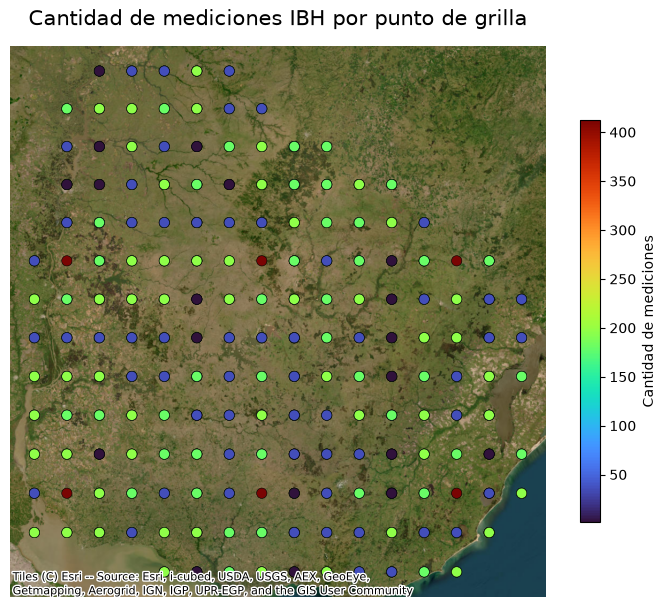

In [101]:
# 1. Contar mediciones por punto (por id)
conteo = IBH_registros.groupby("id").agg(
    n_mediciones=("value", "size"),
    geometry=("geometry", "first")
).reset_index()

# 2. GeoDataFrame y reproyección a Web Mercator (necesario para el fondo)
gdf = gpd.GeoDataFrame(conteo, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)

# 3. Figura
fig, ax = plt.subplots(figsize=(7, 7))

# 4. Puntos coloreados por cantidad de mediciones + escala de referencia
gdf.plot(
    ax=ax,
    column="n_mediciones",
    cmap="turbo",              # rampa vistosa; probá "YlOrRd" o "plasma"
    markersize=55,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "Cantidad de mediciones", "shrink": 0.6},
    zorder=2
)

# 5. Mapa geográfico de fondo (Uruguay real)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)   # satelital
# Si preferís mapa tipo calle/relieve en vez de satelital, usá:
# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Cantidad de mediciones IBH por punto de grilla", fontsize=15, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

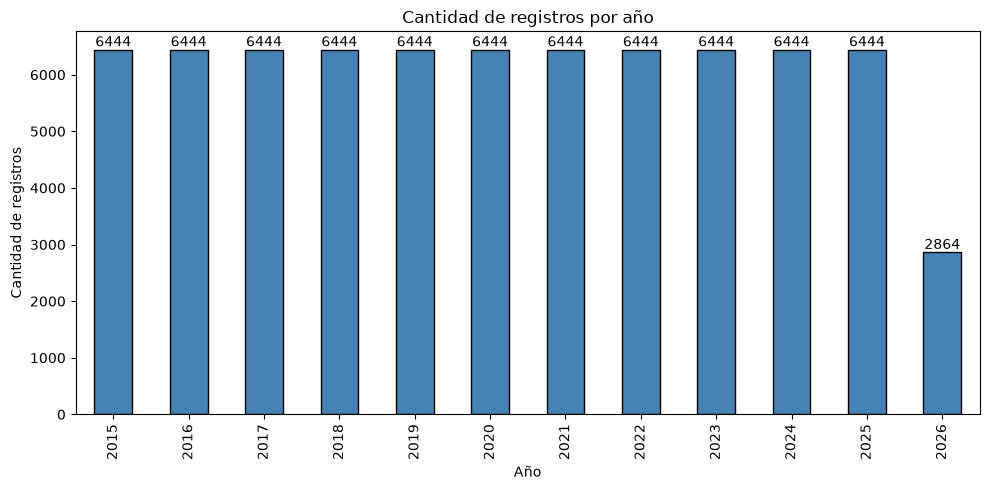

In [102]:
IBH_registros["año"] = pd.to_datetime(IBH_registros["fecha_inicio"]).dt.year.astype("Int64")

por_año = IBH_registros["año"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = por_año.plot(kind="bar", color="steelblue", edgecolor="black")

for i, v in enumerate(por_año):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

In [78]:
type(IBH_registr)

geopandas.geodataframe.GeoDataFrame

In [49]:
mediciones_ANR = df_puntos_mediciones[df_puntos_mediciones["type"] == "ANR"]
mediciones_ANR

,medicion_id,punto_id,value,type,fecha_inicio,fecha_fin,granularidad
5370,9ab3de2b-7275-9642-ccf8-feb2d06ade5c,c04728d8-baf3-486f-6142-4aaa204f7768,5.949758,ANR,2026-01-01,2026-01-10,PERIODO
5371,869b7653-c0c9-01ce-746c-88a50b64528f,c04728d8-baf3-486f-6142-4aaa204f7768,0.000000,ANR,2026-01-11,2026-01-20,PERIODO
5372,ee2741a9-4629-1f28-8189-f222650280f0,c04728d8-baf3-486f-6142-4aaa204f7768,0.000000,ANR,2026-01-21,2026-01-31,PERIODO
5373,1c9ee25f-e5e6-5688-0f25-ae54efdaecae,c04728d8-baf3-486f-6142-4aaa204f7768,0.000000,ANR,2026-02-01,2026-02-10,PERIODO
5374,cc23cca8-a2e9-ee63-00a6-5a1a9a9f8a93,c04728d8-baf3-486f-6142-4aaa204f7768,0.319524,ANR,2026-02-11,2026-02-20,PERIODO
...,...,...,...,...,...,...,...
221239,ffd44566-c1ae-28d6-e1a0-ccbe563ee4ea,06578bbe-4c37-f6be-ae7a-1657b2d756db,45.010902,ANR,2022-11-11,2022-11-20,PERIODO
221240,d4ad712d-c399-d9ec-0408-733e5e9be1af,06578bbe-4c37-f6be-ae7a-1657b2d756db,39.025715,ANR,2022-11-21,2022-11-30,PERIODO
221241,3ae249dc-8529-6455-674d-9cf124c728ec,06578bbe-4c37-f6be-ae7a-1657b2d756db,23.657518,ANR,2022-12-01,2022-12-10,PERIODO
221242,664f233e-7eb5-5213-6b57-b52207e89ac1,06578bbe-4c37-f6be-ae7a-1657b2d756db,15.551336,ANR,2022-12-11,2022-12-20,PERIODO


In [53]:
ANR_registros = df_puntos_grilla.merge(mediciones_ANR,
                                          left_on = "id",
                                          right_on ="punto_id",
                                          how = "left"
                                          ).drop(columns=["punto_id", "medicion_id"])

ANR_registros.head()

,id,geometry,value,type,fecha_inicio,fecha_fin,granularidad
0,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),0.000000,ANR,2015-01-01,2015-01-10,PERIODO
1,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),2.151410,ANR,2015-01-11,2015-01-20,PERIODO
2,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),24.709478,ANR,2015-01-21,2015-01-31,PERIODO
3,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),0.139433,ANR,2015-02-01,2015-02-10,PERIODO
4,35712c62-3e1e-7f71-da06-1c8a1e5c2288,POINT (-57 -34.6667),0.975903,ANR,2015-02-11,2015-02-20,PERIODO


In [54]:
#mapa

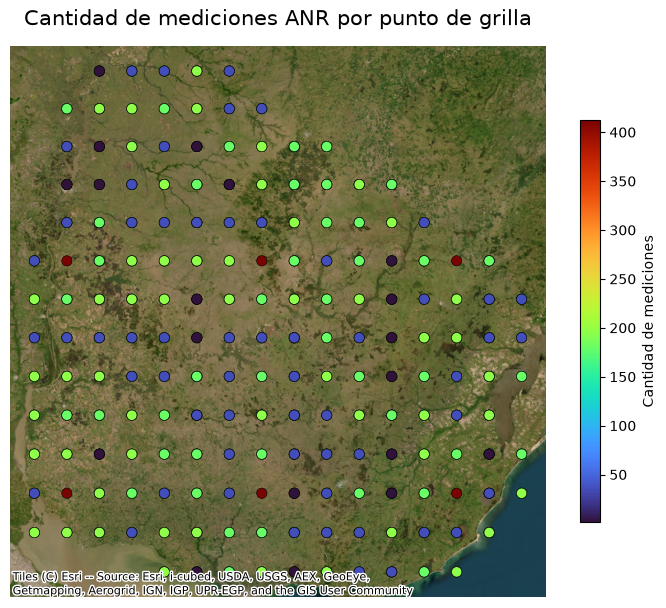

In [100]:


# 1. Contar mediciones por punto (por id)
conteo = ANR_registros.groupby("id").agg(
    n_mediciones=("value", "size"),
    geometry=("geometry", "first")
).reset_index()

# 2. GeoDataFrame y reproyección a Web Mercator (necesario para el fondo)
gdf = gpd.GeoDataFrame(conteo, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)

# 3. Figura
fig, ax = plt.subplots(figsize=(7, 7))

# 4. Puntos coloreados por cantidad de mediciones + escala de referencia
gdf.plot(
    ax=ax,
    column="n_mediciones",
    cmap="turbo",              # rampa vistosa; probá "YlOrRd" o "plasma"
    markersize=55,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "Cantidad de mediciones", "shrink": 0.6},
    zorder=2
)

# 5. Mapa geográfico de fondo (Uruguay real)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)   # satelital
# Si preferís mapa tipo calle/relieve en vez de satelital, usá:
# cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Cantidad de mediciones ANR por punto de grilla", fontsize=15, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

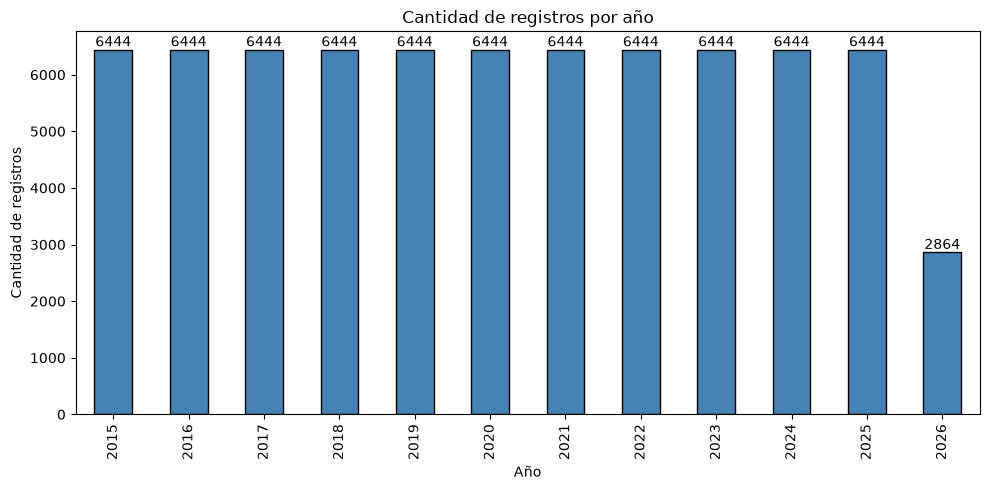

In [88]:
ANR_registros["año"] = pd.to_datetime(ANR_registros["fecha_inicio"]).dt.year.astype("Int64")

por_año = ANR_registros["año"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = por_año.plot(kind="bar", color="steelblue", edgecolor="black")

for i, v in enumerate(por_año):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

In [77]:
type(ANR_registros)

geopandas.geodataframe.GeoDataFrame

In [80]:
inumet_registros.to_file("../export/joins/inumet_registros.geojson", driver="GeoJSON")
clima_registros.to_file("../export/joins/clima_resgistros.geojson", driver="GeoJSON")
erosions_registros.to_file("../export/joins/erosion_suelos.geojson", driver="GeoJSON")
erosionc_registros.to_file("../export/joins/erosion_cuencas.geojson", driver="GeoJSON")
PAD_registros.to_file("../export/joins/PAD_registros.geojson", driver="GeoJSON")
IBH_registros.to_file("../export/joins/IBH_registros.geojson", driver="GeoJSON")
ANR_registros.to_file("../export/joins/ANR_registros.geojson", driver="GeoJSON")

In [92]:
df_g = pd.read_csv("../export/gemsparams.csv")

In [93]:
print("Fecha mínima:", df_g["fecha_inicio"].min())
print("Fecha máxima:", df_g["fecha_inicio"].max())

Fecha mínima: 2015-01-02 00:00:00
Fecha máxima: 2023-08-02 14:35:00
